# Offline Ternary Hex Animation from Saved Runs

This notebook loads saved run artifacts and builds ternary hex-density animations without rerunning training.

Expected run payloads:
- dict with `data` containing snapshot list, or
- raw snapshot list

Snapshot format expected from `SelectionMethod.helper`: each snapshot has keys like `yh` / `yvh` (log-probs).

In [1]:
from pathlib import Path
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.patches import Polygon
from IPython.display import HTML
import re

In [2]:
import os

# adjust the number of .parent calls to match how deep the notebook is nested
project_root = Path.cwd().parent  # if notebook is one level below root
os.chdir(project_root)
print('Working dir now:', Path.cwd())

Working dir now: /home/todd30ap/online-batch-selection


In [3]:
def load_run_payload(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return torch.load(path, map_location='cpu', weights_only=False)

def get_ts(bs=320, epochs=200, save_init=5, save_freq=4, len_data=50000):
    t = 0
    ts = [t]
    n_batches = len_data // bs
    for epoch in range(epochs):
        for i in range(n_batches):
            t += 1
            if epoch < save_init and i % (n_batches // save_freq) == 0:
                ts.append(t)

        if save_init <= epoch <= 25:
            ts.append(t)
        elif 25 < epoch <= 65 and epoch % 4 == 0:
            ts.append(t)
        elif epoch > 65 and epoch % 15 == 0 or (epoch == epochs - 1):
            ts.append(t)
    return ts

def extract_snapshots(payload):
    if isinstance(payload, dict) and 'data' in payload:
        snapshots = payload['data']
    elif isinstance(payload, str):
        return load_snapshots(payload)
    else:
        snapshots = payload
    if not isinstance(snapshots, (list, tuple)):
        raise ValueError('Could not find snapshot list in run artifact.')
    if len(snapshots) == 0:
        raise ValueError('Snapshot list is empty.')
    return list(snapshots)

def load_snapshots(snapshot_dir):
    snapshot_dir = Path(snapshot_dir)
    if not snapshot_dir.exists():
        raise FileNotFoundError(f"Snapshot directory does not exist: {snapshot_dir}")
    if not snapshot_dir.is_dir():
        raise NotADirectoryError(f"Expected a directory, but got: {snapshot_dir}")

    def extract_index(path):
        match = re.search(r'(\d+)', path.stem)
        if match is None:
            raise ValueError(f"Could not find a numeric index in filename: {path.name}")
        return int(match.group(1))

    # Sort paths numerically by checkpoint index before loading anything
    paths = sorted(snapshot_dir.iterdir(), key=extract_index)

    snapshots = []
    for path in paths:
        if path.is_dir():
            raise ValueError(f"Expected a snapshot file, but found a directory: {path}")

        snapshot = torch.load(path, map_location='cpu', weights_only=False)

        if not isinstance(snapshot, dict):
            raise TypeError(f"Expected snapshot {path} to contain a dictionary, but found {type(snapshot).__name__}")
        snapshots.append(snapshot)

    return snapshots



def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def snapshot_to_ternary(snapshot, split_key='yh', ternary_mode='first3'):
    if split_key not in snapshot:
        raise KeyError(f"Snapshot missing key '{split_key}'. Available: {list(snapshot.keys())}")

    log_probs = _to_numpy(snapshot[split_key])
    probs = np.exp(log_probs)

    if probs.ndim != 2:
        raise ValueError(f'Expected 2D probabilities, got shape {probs.shape}')

    c = probs.shape[1]
    if c >= 3:
        if ternary_mode == 'first3':
            tri = probs[:, :3]
        elif ternary_mode == 'top3':
            top3_idx = np.argsort(probs, axis=1)[:, -3:]
            tri = np.take_along_axis(probs, top3_idx, axis=1)
        else:
            raise ValueError('ternary_mode must be first3 or top3')
    elif c == 2:
        third = np.clip(1.0 - probs.sum(axis=1, keepdims=True), 0.0, 1.0)
        tri = np.concatenate([probs, third], axis=1)
    else:
        raise ValueError(f'Need >=2 classes to project to ternary, got {c}')

    denom = np.clip(tri.sum(axis=1, keepdims=True), 1e-12, None)
    return tri / denom

def barycentric_to_cartesian(bary):
    v0 = np.array([0.0, 0.0])
    v1 = np.array([1.0, 0.0])
    v2 = np.array([0.5, math.sqrt(3) / 2.0])
    return bary[:,0:1]*v0 + bary[:,1:2]*v1 + bary[:,2:3]*v2


def load_true_labels_for_run(run_path, dataset, split_key='yh'):
    labels_path = Path(f'./labels/{dataset}.p')
    if not labels_path.exists():
        raise FileNotFoundError(f'Missing label file: {labels_path}')

    labels_payload = torch.load(labels_path, map_location='cpu', weights_only=False)
    if not isinstance(labels_payload, dict):
        raise ValueError(f'Unexpected label payload format in {labels_path}')

    split = 'train' if split_key == 'yh' else 'val'
    if split not in labels_payload:
        raise KeyError(f"Label file missing split '{split}'. Available: {list(labels_payload.keys())}")

    labels = np.asarray(labels_payload[split]).astype(int)
    return labels, labels_path

In [4]:
def make_ternary_hex_animation(
    snapshots,
    ts,
    title,
    split_key='yh',
    ternary_mode='first3',
    class_index=None,
    true_labels=None,
    gridsize=24,
    cmap='viridis',
    norm='sqrt',
    interval=150,
    corner_labels=('Class 0', 'Class 1', 'Class 2'),
    save_mp4=False,
    save_png_frames=False,
    png_dir=None,
    frame_prefix='frame',
    out_name='ternary_hex_offline',
    progress_threshold=None
):
    y_max = math.sqrt(3) / 2.0

    bary_frames = [snapshot_to_ternary(s, split_key=split_key, ternary_mode=ternary_mode) for s in snapshots]

    if class_index is not None:
        cls = int(class_index)
        if cls < 0 or cls > 2:
            raise ValueError('class_index must be one of {0,1,2} or None')
        if true_labels is None:
            raise ValueError('true_labels is required when class_index is set')

        labels_arr = np.asarray(true_labels).astype(int)
        filtered = []
        class_counts = []
        for b in bary_frames:
            if labels_arr.shape[0] != b.shape[0]:
                raise ValueError(
                    f'true_labels length ({labels_arr.shape[0]}) does not match snapshot rows ({b.shape[0]})'
                )
            keep = labels_arr == cls
            bf = b[keep]
            class_counts.append(int(bf.shape[0]))
            if bf.shape[0] == 0:
                bf = np.array([[1/3, 1/3, 1/3]], dtype=float)
            filtered.append(bf)
        bary_frames = filtered
        vmax = float(max(class_counts) if len(class_counts) > 0 else 1)
    else:
        frame_sizes = [int(b.shape[0]) for b in bary_frames]
        vmax = float(max(frame_sizes) if len(frame_sizes) > 0 else 1)

    vmax = max(vmax, 1.0)
    cart_frames = [barycentric_to_cartesian(b) for b in bary_frames]

    norm_name = str(norm).lower()
    is_log_norm = False
    if norm_name == 'linear':
        density_norm = mcolors.Normalize(vmin=0.0, vmax=vmax, clip=True)
    elif norm_name == 'log':
        # LogNorm cannot accept zero; use 1 as the minimum displayed color value
        # and show a separate '0' label below the colorbar. This preserves
        # logarithmic spacing for positive integer densities while allowing a
        # visible indicator for zero counts.
        is_log_norm = True
        density_norm = mcolors.LogNorm(vmin=1, vmax=max(vmax, 1.0), clip=True)
    else:
        density_norm = mcolors.PowerNorm(gamma=0.5, vmin=0.0, vmax=vmax, clip=True)

    fig, ax = plt.subplots(figsize=(6, 6))
    verts = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, y_max], [0.0, 0.0]])
    ax.plot(verts[:, 0], verts[:, 1], color='black', linewidth=1.2, zorder=5)

    left_label, right_label, top_label = corner_labels
    ax.text(0.0, -0.025, left_label, ha='left', va='top', fontsize=10)
    ax.text(1.0, -0.025, right_label, ha='right', va='top', fontsize=10)
    ax.text(0.5, y_max + 0.006, top_label, ha='center', va='bottom', fontsize=10)

    mid_bary = np.array([[0.0, 0.5, 0.5], [0.5, 0.0, 0.5], [0.5, 0.5, 0.0]])
    centroid_bary = np.array([[1/3, 1/3, 1/3]])
    mid_cart = barycentric_to_cartesian(mid_bary)
    centroid_cart = barycentric_to_cartesian(centroid_bary)[0]
    for m in mid_cart:
        ax.plot([m[0], centroid_cart[0]], [m[1], centroid_cart[1]], color='white', linewidth=1.2, zorder=7)

    clip_poly = Polygon(verts[:-1], closed=True, transform=ax.transData)

    hb = ax.hexbin(
        cart_frames[0][:, 0],
        cart_frames[0][:, 1],
        gridsize=gridsize,
        cmap=cmap,
        norm=density_norm,
        mincnt=0,
        extent=(0.0, 1.0, 0.0, y_max),
        linewidths=0.0,
        alpha=0.95,
        zorder=2,
    )
    hb.set_clip_path(clip_poly)
    cbar = fig.colorbar(hb, ax=ax, label='Point density')
    if is_log_norm:
        import matplotlib.ticker as mticker

        def _log_ticks(maxval):
            # Build a set of integer ticks spaced roughly logarithmically:
            # values like 1,2,5,10,20,50,... up to maxval
            ticks = []
            maxval = max(1, int(maxval))
            max_exp = int(math.log10(maxval)) if maxval > 0 else 0
            for exp in range(0, max_exp + 1):
                for m in (1, 2, 5):
                    v = m * (10 ** exp)
                    if v <= maxval:
                        ticks.append(int(v))
            ticks = sorted(set(ticks))
            if ticks[-1] != int(maxval):
                ticks.append(int(maxval))
            return ticks

        ticks = _log_ticks(int(max(vmax, 1)))
        cbar.set_ticks(ticks)
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
        # Add a '0' label below the colorbar to indicate zero-count bins.
        cbar.ax.text(0.5, -0.03, '0', transform=cbar.ax.transAxes, ha='center', va='top')

    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, y_max + 0.05)

    fig.subplots_adjust(bottom=0.15)

    def frame_title(i):
        cls_txt = 'all' if class_index is None else corner_labels[class_index]
        return f'{title} ({cls_txt}) - step {ts[i]}'

    frame_text = ax.text(
            0.5, -0.12,
            "",            # initial text
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=11,
            clip_on=False
        )

    def draw_frame(i):
        nonlocal hb
        if hb is not None:
            hb.remove()
        cur = cart_frames[i]
        hb = ax.hexbin(
            cur[:, 0],
            cur[:, 1],
            gridsize=gridsize,
            cmap=cmap,
            norm=density_norm,
            mincnt=0,
            extent=(0.0, 1.0, 0.0, y_max),
            linewidths=0.0,
            alpha=0.95,
            zorder=2,
        )
        hb.set_clip_path(clip_poly)
        cbar.update_normal(hb)
        ax.set_title(frame_title(i), fontsize=14, pad=22)
        frame_text.set_text(f"Current Method: {snapshots[i]['method']}     Progress Threshold: {progress_threshold}")
        return hb, frame_text

    def update(i):
        return draw_frame(i)

    draw_frame(0)

    if save_png_frames:
        png_root = Path(png_dir) if png_dir is not None else Path(out_name).parent / f'{Path(out_name).stem}_frames'
        png_root.mkdir(parents=True, exist_ok=True)
        for i in range(len(cart_frames)):
            draw_frame(i)
            fig.savefig(png_root / f'{frame_prefix}_{i:04d}.png', dpi=150, bbox_inches='tight')
        draw_frame(0)
        print('Saved PNG frames to', png_root.resolve())

    ani = FuncAnimation(fig, update, frames=len(cart_frames), interval=interval, blit=False)

    if save_mp4:
        out_path = Path(f'{out_name}.mp4')
        out_path.parent.mkdir(parents=True, exist_ok=True)
        try:
            import imageio_ffmpeg as iioff
            plt.rcParams['animation.ffmpeg_path'] = iioff.get_ffmpeg_exe()
        except Exception:
            pass
        writer = FFMpegWriter(fps=max(1, int(1000 / max(interval, 1))), bitrate=1800)
        ani.save(str(out_path), writer=writer, dpi=150)
        print('Saved', out_path.resolve())

    return fig, ani

In [ ]:
# Find candidate run files
results_root = Path('results')
candidates = sorted(results_root.rglob('*.p')) + sorted(results_root.rglob('*.pt')) + sorted(results_root.rglob('*.pth'))
for p in candidates[:40]:
    print(p)
print(f'Found {len(candidates)} candidate files')

Loaded snapshots: 120
Loaded true labels from: labels/CIFAR3.p
True label count: 15000
Saved PNG frames to /home/todd30ap/online-batch-selection/new/plots/ternary/two_methods/pngs/CIFAR3/RhoLoss-DivBS_thr-0.0_lr_0.01_seed1
Saved /home/todd30ap/online-batch-selection/new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-0.0_lr-0.01_seed1.mp4
Loaded snapshots: 120
Loaded true labels from: labels/CIFAR3.p
True label count: 15000
Saved PNG frames to /home/todd30ap/online-batch-selection/new/plots/ternary/two_methods/pngs/CIFAR3/RhoLoss-DivBS_thr-0.1_lr_0.01_seed1
Saved /home/todd30ap/online-batch-selection/new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-0.1_lr-0.01_seed1.mp4
Loaded snapshots: 120
Loaded true labels from: labels/CIFAR3.p
True label count: 15000
Saved PNG frames to /home/todd30ap/online-batch-selection/new/plots/ternary/two_methods/pngs/CIFAR3/RhoLoss-DivBS_thr-0.2_lr_0.01_seed1
Saved /home/todd30ap/online-batch-selection/new/plots/ternary/two_m

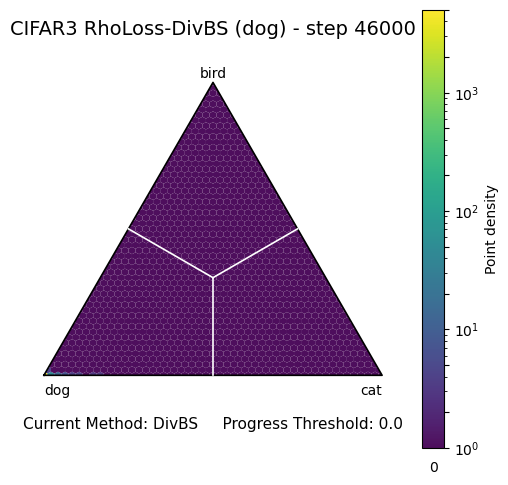

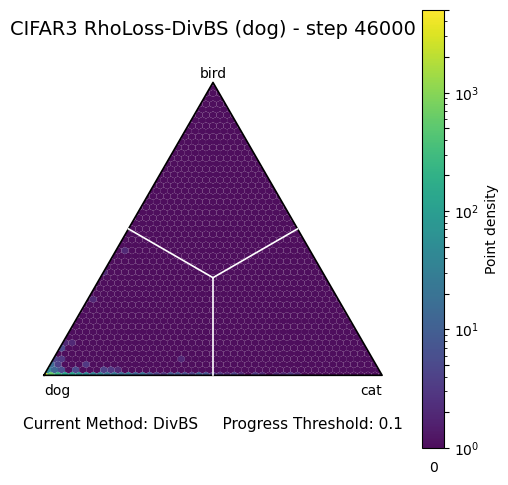

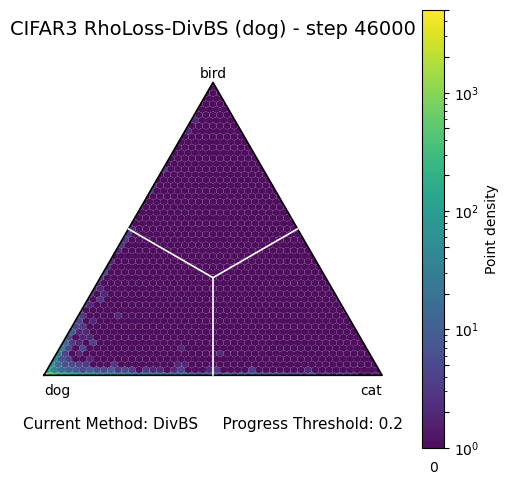

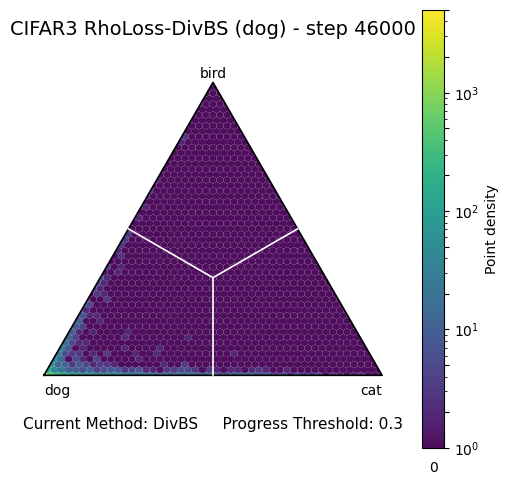

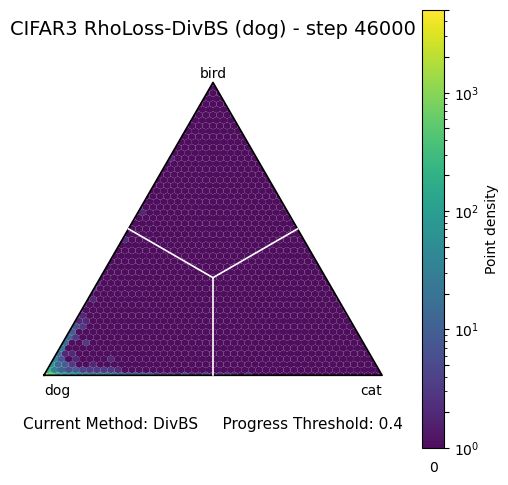

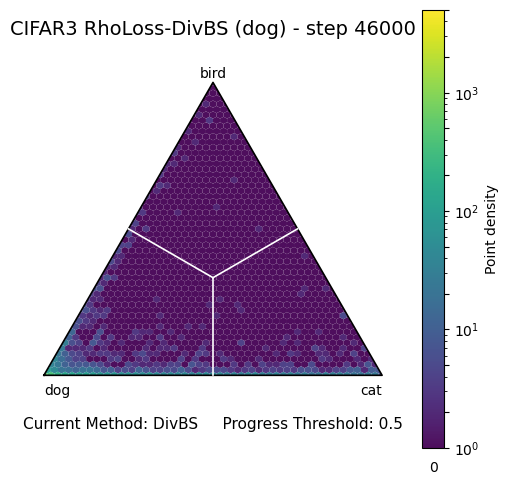

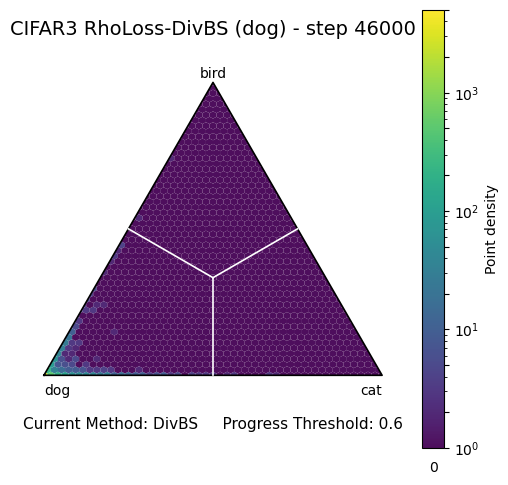

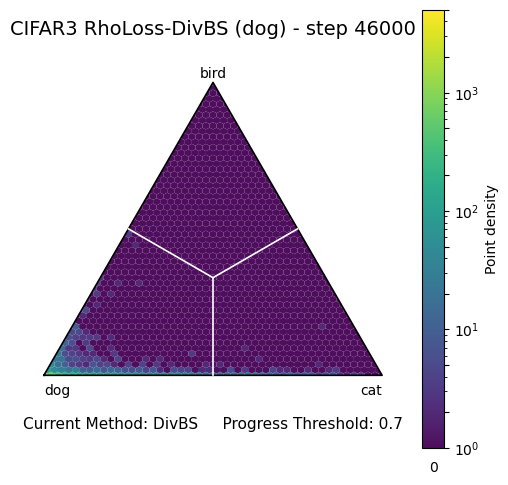

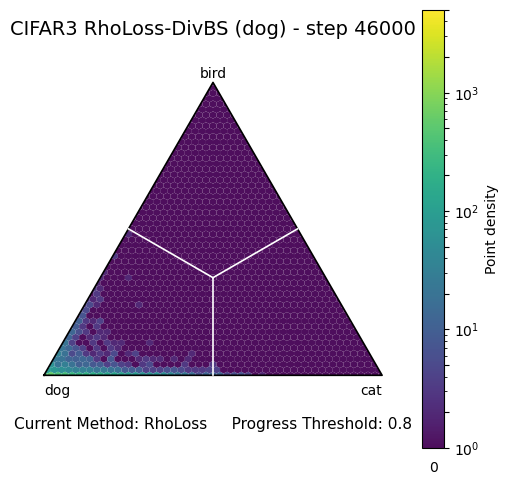

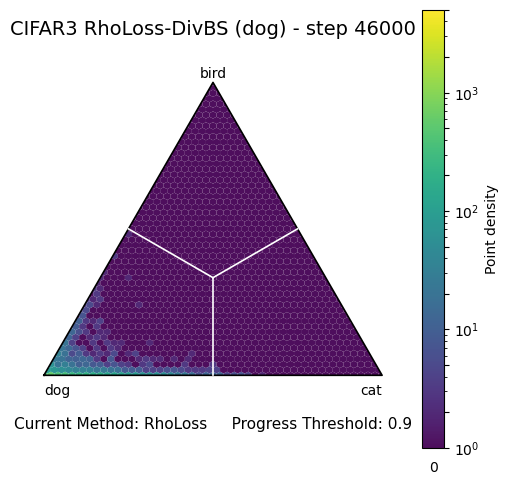

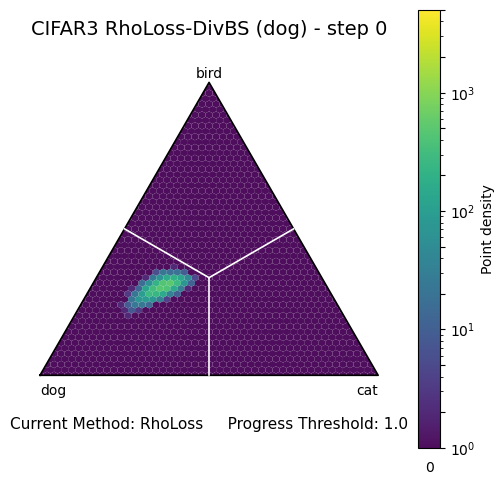

In [5]:
dataset = 'CIFAR3'

for method in ["RhoLoss-DivBS"]:
    for threshold, run_path in [
        (0.0, "./experiments/cifar3_RhoLoss-DivBS/8-6-26/20260806_095323_CIFAR3_RhoLoss_DivBS_progThreshold-0.0_Seed-1/logs/log_probs"), 
        (0.1, "./experiments/cifar3_RhoLoss-DivBS/8-6-26/20260806_095323_CIFAR3_RhoLoss_DivBS_progThreshold-0.1_Seed-1/logs/log_probs"), 
        (0.2, "./experiments/cifar3_RhoLoss-DivBS/8-6-26/20260806_095330_CIFAR3_RhoLoss_DivBS_progThreshold-0.2_Seed-1/logs/log_probs"), 
        (0.3, "./experiments/cifar3_RhoLoss-DivBS/8-6-26/20260806_095330_CIFAR3_RhoLoss_DivBS_progThreshold-0.3_Seed-1/logs/log_probs"), 
        (0.4, "./experiments/cifar3_RhoLoss-DivBS/8-6-26/20260806_095330_CIFAR3_RhoLoss_DivBS_progThreshold-0.4_Seed-1/logs/log_probs"), 
        (0.5, "./experiments/cifar3_RhoLoss-DivBS/8-6-26/20260806_095331_CIFAR3_RhoLoss_DivBS_progThreshold-0.5_Seed-1/logs/log_probs"), 
        (0.6, "./experiments/cifar3_RhoLoss-DivBS/8-6-26/20260806_095342_CIFAR3_RhoLoss_DivBS_progThreshold-0.6_Seed-1/logs/log_probs"), 
        (0.7, "./experiments/cifar3_RhoLoss-DivBS/8-6-26/20260806_095343_CIFAR3_RhoLoss_DivBS_progThreshold-0.7_Seed-1/logs/log_probs"), 
        (0.8, "./experiments/cifar3_RhoLoss-DivBS/8-6-26/20260806_095343_CIFAR3_RhoLoss_DivBS_progThreshold-0.8_Seed-1/logs/log_probs"), 
        (0.9, "./experiments/cifar3_RhoLoss-DivBS/8-6-26/20260806_095343_CIFAR3_RhoLoss_DivBS_progThreshold-0.9_Seed-1/logs/log_probs"), 
        (1.0, "./experiments/cifar3_RhoLoss-DivBS/8-6-26/20260806_095333_CIFAR3_RhoLoss_DivBS_progThreshold-1.0_Seed-1/logs/log_probs")
    ]:

        """
        (0.0, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161337_CIFAR3_DivBS_RhoLoss_progThreshold-0_Seed-1/logs/log_probs"), 
        (0.1, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161327_CIFAR3_DivBS_RhoLoss_progThreshold-0.1_Seed-1/logs/log_probs"), 
        (0.2, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161336_CIFAR3_DivBS_RhoLoss_progThreshold-0.2_Seed-1/logs/log_probs"), 
        (0.3, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161336_CIFAR3_DivBS_RhoLoss_progThreshold-0.3_Seed-1/logs/log_probs"), 
        (0.4, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161336_CIFAR3_DivBS_RhoLoss_progThreshold-0.4_Seed-1/logs/log_probs"), 
        (0.5, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161338_CIFAR3_DivBS_RhoLoss_progThreshold-0.5_Seed-1/logs/log_probs"), 
        (0.6, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161338_CIFAR3_DivBS_RhoLoss_progThreshold-0.6_Seed-1/logs/log_probs"), 
        (0.7, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161337_CIFAR3_DivBS_RhoLoss_progThreshold-0.7_Seed-1/logs/log_probs"), 
        (0.8, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161346_CIFAR3_DivBS_RhoLoss_progThreshold-0.8_Seed-1/logs/log_probs"), 
        (0.9, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161342_CIFAR3_DivBS_RhoLoss_progThreshold-0.9_Seed-1/logs/log_probs"), 
        (1.0, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161349_CIFAR3_DivBS_RhoLoss_progThreshold-1.0_Seed-1/logs/log_probs")
        """

        """
        (0.0, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161337_CIFAR3_DivBS_RhoLoss_progThreshold-0_Seed-1/logs/log_probs"), 
        (0.1, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161327_CIFAR3_DivBS_RhoLoss_progThreshold-0.1_Seed-1/logs/log_probs"), 
        (0.2, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161336_CIFAR3_DivBS_RhoLoss_progThreshold-0.2_Seed-1/logs/log_probs"), 
        (0.3, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161336_CIFAR3_DivBS_RhoLoss_progThreshold-0.3_Seed-1/logs/log_probs"), 
        (0.4, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161336_CIFAR3_DivBS_RhoLoss_progThreshold-0.4_Seed-1/logs/log_probs"), 
        (0.5, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161338_CIFAR3_DivBS_RhoLoss_progThreshold-0.5_Seed-1/logs/log_probs"), 
        (0.6, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161338_CIFAR3_DivBS_RhoLoss_progThreshold-0.6_Seed-1/logs/log_probs"), 
        (0.7, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161337_CIFAR3_DivBS_RhoLoss_progThreshold-0.7_Seed-1/logs/log_probs"), 
        (0.8, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161346_CIFAR3_DivBS_RhoLoss_progThreshold-0.8_Seed-1/logs/log_probs"), 
        (0.9, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161342_CIFAR3_DivBS_RhoLoss_progThreshold-0.9_Seed-1/logs/log_probs"), 
        (1.0, "./experiments/cifar3_two-methods_RESNET/7-29-26/20260729_161349_CIFAR3_DivBS_RhoLoss_progThreshold-1.0_Seed-1/logs/log_probs")

        (0.0, "./experiments/cifar3_RhoLoss-DivBS/lr0.01/7-30-26/20260730_164541_CIFAR3_RhoLoss_DivBS_progThreshold-0.0_Seed-1/logs/log_probs"), 
                (0.1, "./experiments/cifar3_RhoLoss-DivBS/lr0.01/7-30-26/20260730_164540_CIFAR3_RhoLoss_DivBS_progThreshold-0.1_Seed-1/logs/log_probs"), 
                (0.2, "./experiments/cifar3_RhoLoss-DivBS/lr0.01/7-30-26/20260730_164543_CIFAR3_RhoLoss_DivBS_progThreshold-0.2_Seed-1/logs/log_probs"), 
                (0.3, "./experiments/cifar3_RhoLoss-DivBS/lr0.01/7-30-26/20260730_164543_CIFAR3_RhoLoss_DivBS_progThreshold-0.3_Seed-1/logs/log_probs"), 
                (0.4, "./experiments/cifar3_RhoLoss-DivBS/lr0.01/7-30-26/20260730_164544_CIFAR3_RhoLoss_DivBS_progThreshold-0.4_Seed-1/logs/log_probs"), 
                (0.5, "./experiments/cifar3_RhoLoss-DivBS/lr0.01/7-30-26/20260730_164543_CIFAR3_RhoLoss_DivBS_progThreshold-0.5_Seed-1/logs/log_probs"), 
                (0.6, "./experiments/cifar3_RhoLoss-DivBS/lr0.01/7-30-26/20260730_164544_CIFAR3_RhoLoss_DivBS_progThreshold-0.6_Seed-1/logs/log_probs"), 
                (0.7, "./experiments/cifar3_RhoLoss-DivBS/lr0.01/7-30-26/20260730_164544_CIFAR3_RhoLoss_DivBS_progThreshold-0.7_Seed-1/logs/log_probs"), 
                (0.8, "./experiments/cifar3_RhoLoss-DivBS/lr0.01/7-30-26/20260730_164544_CIFAR3_RhoLoss_DivBS_progThreshold-0.8_Seed-1/logs/log_probs"), 
                (0.9, "./experiments/cifar3_RhoLoss-DivBS/lr0.01/7-30-26/20260730_165030_CIFAR3_RhoLoss_DivBS_progThreshold-0.9_Seed-1/logs/log_probs"), 
                (1.0, "./experiments/cifar3_RhoLoss-DivBS/lr0.01/7-30-26/20260730_170250_CIFAR3_RhoLoss_DivBS_progThreshold-1.0_Seed-1/logs/log_probs")
        """

        anim_out_root = Path(f'./new/plots/ternary/two_methods/animations/{dataset}/{method}_thr-{threshold}_lr-0.01_seed1')
        png_out_root = Path(f'./new/plots/ternary/two_methods/pngs/{dataset}/{method}_thr-{threshold}_lr_0.01_seed1')
        # run_path = './experiments/cifar3_two_methods/debug/20260723_142814_CIFAR3_DivBS_RhoLoss_progThreshold-0.5_Seed-1/progress_snapshots'

        # ts = get_ts(bs=50, epochs=25, save_init=5, save_freq=4, len_data=1000)
        ts = get_ts(epochs=1000, len_data=15000)
        split_key = 'yh'  # 'yh' for train snapshots, 'yvh' for validation snapshots

        if run_path is None:
            print('Set run_path first')
        else:
            # payload = load_run_payload(run_path)
            payload = run_path
            snapshots = extract_snapshots(payload)
            print('Loaded snapshots:', len(snapshots))

            true_labels = None
            labels_path = None
            try:
                true_labels, labels_path = load_true_labels_for_run(run_path, dataset, split_key=split_key)
                print('Loaded true labels from:', labels_path)
                print('True label count:', len(true_labels))
            except Exception as e:
                print('Could not load true labels:', e)
                print('If class_index is set, a matching labels_{dataset}.p file is required.')

        if run_path is not None:
            fig, ani = make_ternary_hex_animation(
                snapshots=snapshots,
                ts=ts,
                title=f'{dataset} {method}',
                split_key=split_key,
                ternary_mode='first3',
                class_index=0,
                true_labels=true_labels,
                gridsize=48,
                cmap='viridis',
                norm='log',
                interval=200,
                corner_labels=('dog', 'cat', 'bird'),
                save_mp4=True,
                save_png_frames=True,
                png_dir=png_out_root,
                out_name=str(anim_out_root),
                progress_threshold=threshold
            )
            HTML(ani.to_jshtml())

In [ ]:
test_snapshots = [
    {'yh': np.log(np.array([[0.7, 0.2, 0.1], [0.2, 0.6, 0.2], [0.15, 0.25, 0.6]]))},
    {'yh': np.log(np.array([[0.6, 0.3, 0.1], [0.25, 0.5, 0.25], [0.2, 0.2, 0.6]]))},
]

fig, ani = make_ternary_hex_animation(
    snapshots=test_snapshots,
    ts=[0, 1],
    title='png export smoke test',
    save_mp4=False,
    save_png_frames=True,
    png_dir=Path('./plots/frames/test_hex_png_frames'),
    corner_labels=('A', 'B', 'C'),
)

plt.close(fig)

In [7]:
import subprocess
import imageio_ffmpeg as iioff

def combine_mp4s_to_grid(mp4_paths, out_path, grid_shape=None):
    """
    mp4_paths: list of paths to input .mp4 files (row-major order)
    out_path: output .mp4 path
    grid_shape: (rows, cols). If None, inferred as a single row
                (rows=1, cols=len(mp4_paths)) unless len==9, in which
                case it defaults to 3x3.
    """
    mp4_paths = [str(Path(p)) for p in mp4_paths]
    n = len(mp4_paths)

    if grid_shape is None:
        if n == 9:
            grid_shape = (3, 3)
        else:
            grid_shape = (1, n)

    rows, cols = grid_shape
    if rows * cols != n:
        raise ValueError(f'grid_shape {grid_shape} does not match {n} input videos')

    ffmpeg_bin = iioff.get_ffmpeg_exe()

    # Build xstack layout string: each input's (x,y) offset in terms of
    # previous inputs' widths/heights. Assumes all inputs share the same
    # per-tile width/height (w0/h0 from the first stream).
    layout_positions = []
    for r in range(rows):
        for c in range(cols):
            x = '+'.join([f'w{i}' for i in range(c)]) if c > 0 else '0'
            y = '+'.join([f'h{i}' for i in range(r * cols)]) if r > 0 else '0'
            layout_positions.append(f'{x}_{y}')
    layout = '|'.join(layout_positions)

    inputs = []
    for p in mp4_paths:
        inputs += ['-i', p]

    filter_complex = f'xstack=inputs={n}:layout={layout}'

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    cmd = [
        ffmpeg_bin, '-y',
        *inputs,
        '-filter_complex', filter_complex,
        '-c:v', 'libx264',
        '-pix_fmt', 'yuv420p',
        str(out_path),
    ]
    subprocess.run(cmd, check=True)
    print('Saved', out_path.resolve())

In [8]:
combine_mp4s_to_grid(
    mp4_paths=[
        './new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-0.0_lr-0.01_seed1.mp4',
        './new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-0.5_lr-0.01_seed1.mp4',
        './new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-1.0_lr-0.01_seed1.mp4',
    ],
    out_path='./new/plots/ternary/two_methods/combined_R-D/CIFAR3_row_thr_0.0_0.5_1.0_lr-0.01.mp4',
)

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/todd30ap/.conda/envs/online-bs-p100 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable

Saved /home/todd30ap/online-batch-selection/new/plots/ternary/two_methods/combined_R-D/CIFAR3_row_thr_0.0_0.5_1.0_lr-0.01.mp4


[out#0/mp4 @ 0x557a4988d640] video:1301KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.173308%
frame=  120 fps=0.0 q=-1.0 Lsize=    1303KiB time=00:00:23.60 bitrate= 452.2kbits/s speed=25.2x    
[libx264 @ 0x557a49878d00] frame I:1     Avg QP:14.14  size:196299
[libx264 @ 0x557a49878d00] frame P:30    Avg QP:15.79  size: 14240
[libx264 @ 0x557a49878d00] frame B:89    Avg QP:20.48  size:  7950
[libx264 @ 0x557a49878d00] consecutive B-frames:  0.8%  0.0%  2.5% 96.7%
[libx264 @ 0x557a49878d00] mb I  I16..4: 22.8% 54.2% 23.0%
[libx264 @ 0x557a49878d00] mb P  I16..4:  0.0%  0.1%  0.2%  P16..4:  4.4%  1.1%  1.0%  0.0%  0.0%    skip:93.2%
[libx264 @ 0x557a49878d00] mb B  I16..4:  0.0%  0.4%  0.1%  B16..8:  3.3%  0.7%  0.7%  direct: 0.9%  skip:93.9%  L0:47.6% L1:43.5% BI: 8.9%
[libx264 @ 0x557a49878d00] 8x8 transform intra:58.6% inter:25.6%
[libx264 @ 0x557a49878d00] coded y,uvDC,uvAC intra: 20.8% 15.8% 15.1% inter: 2.7% 3.2% 2.7%
[libx264 @ 0x557a49878d0

In [9]:
import subprocess
from pathlib import Path
import imageio_ffmpeg as iioff

def combine_mp4s_to_3x3_grid(mp4_paths, out_path):
    """
    mp4_paths: list of 9 .mp4 paths, row-major order (top-left to bottom-right)
    out_path: output .mp4 path
    Assumes all 9 videos are the same resolution.
    """
    mp4_paths = [str(Path(p)) for p in mp4_paths]
    if len(mp4_paths) != 9:
        raise ValueError(f'Expected exactly 9 videos, got {len(mp4_paths)}')

    ffmpeg_bin = iioff.get_ffmpeg_exe()
    cols = 3

    # Correct layout: x-offset sums widths of tiles to the LEFT in the
    # same row; y-offset sums heights of ONE tile per row above (not
    # all three), since every tile in a row shares the same height.
    layout_positions = []
    for i in range(9):
        r, c = divmod(i, cols)
        x = '+'.join(f'w{r*cols + k}' for k in range(c)) if c > 0 else '0'
        y = '+'.join(f'h{k*cols}' for k in range(r)) if r > 0 else '0'
        layout_positions.append(f'{x}_{y}')
    layout = '|'.join(layout_positions)

    inputs = []
    for p in mp4_paths:
        inputs += ['-i', p]

    filter_complex = f'xstack=inputs=9:layout={layout}'

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    cmd = [
        ffmpeg_bin, '-y',
        *inputs,
        '-filter_complex', filter_complex,
        '-c:v', 'libx264',
        '-pix_fmt', 'yuv420p',
        str(out_path),
    ]
    subprocess.run(cmd, check=True)
    print('Saved', out_path.resolve())

In [10]:
combine_mp4s_to_3x3_grid(
    mp4_paths=[
        './new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-0.0_lr-0.01_seed1.mp4',
        './new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-0.1_lr-0.01_seed1.mp4',
        './new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-0.2_lr-0.01_seed1.mp4',
        './new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-0.3_lr-0.01_seed1.mp4',
        './new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-0.4_lr-0.01_seed1.mp4',
        './new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-0.5_lr-0.01_seed1.mp4',
        './new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-0.6_lr-0.01_seed1.mp4',
        './new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-0.7_lr-0.01_seed1.mp4',
        './new/plots/ternary/two_methods/animations/CIFAR3/RhoLoss-DivBS_thr-1.0_lr-0.01_seed1.mp4',
    ],
    out_path='./new/plots/ternary/two_methods/combined_R-D/CIFAR3_grid_3x3_lr-0.01.mp4',
)

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/todd30ap/.conda/envs/online-bs-p100 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable

Saved /home/todd30ap/online-batch-selection/new/plots/ternary/two_methods/combined_R-D/CIFAR3_grid_3x3_lr-0.01.mp4


In [11]:
import subprocess
import numpy as np
from PIL import Image
import imageio_ffmpeg as iioff

def _extract_frame(mp4_path, ffmpeg_bin, out_png, t=1.0):
    """Grab a single frame (at t seconds) as a PNG for analysis."""
    cmd = [
        ffmpeg_bin, '-y', '-ss', str(t), '-i', str(mp4_path),
        '-frames:v', '1', str(out_png),
    ]
    subprocess.run(cmd, check=True, capture_output=True)


def _detect_content_bbox(png_path, bg_thresh=250, pad=10):
    """Find bounding box of non-white content in the frame."""
    img = np.array(Image.open(png_path).convert('RGB'))
    # Mask: True where pixel is NOT near-white
    mask = np.any(img < bg_thresh, axis=2)
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    if not rows.any() or not cols.any():
        return None  # nothing detected, fall back to no crop
    y0, y1 = np.where(rows)[0][[0, -1]]
    x0, x1 = np.where(cols)[0][[0, -1]]

    h_img, w_img = img.shape[:2]
    x0 = max(0, x0 - pad)
    y0 = max(0, y0 - pad)
    x1 = min(w_img - 1, x1 + pad)
    y1 = min(h_img - 1, y1 + pad)

    w = x1 - x0 + 1
    h = y1 - y0 + 1
    # ffmpeg needs even dimensions for yuv420p
    w -= w % 2
    h -= h % 2
    return w, h, x0, y0


def combine_mp4s_to_grid(mp4_paths, out_path, grid_shape=None, crop=True, bg_thresh=250, pad=10):
    """
    mp4_paths: list of paths to input .mp4 files (row-major order)
    out_path: output .mp4 path
    grid_shape: (rows, cols). Defaults to 1xN, or 3x3 if n==9.
    crop: if True, auto-detect and trim white background margins
          from each tile (using the FIRST video as the reference box,
          applied uniformly to all — since your figures share layout).
    bg_thresh: pixel values >= this (per channel) count as "background".
    pad: pixels of padding to keep around detected content.
    """
    mp4_paths = [str(Path(p)) for p in mp4_paths]
    n = len(mp4_paths)

    if grid_shape is None:
        grid_shape = (3, 3) if n == 9 else (1, n)
    rows, cols = grid_shape
    if rows * cols != n:
        raise ValueError(f'grid_shape {grid_shape} does not match {n} input videos')

    ffmpeg_bin = iioff.get_ffmpeg_exe()

    crop_box = None
    if crop:
        tmp_png = Path('/tmp/_grid_frame_ref.png')
        _extract_frame(mp4_paths[0], ffmpeg_bin, tmp_png)
        crop_box = _detect_content_bbox(tmp_png, bg_thresh=bg_thresh, pad=pad)
        tmp_png.unlink(missing_ok=True)
        if crop_box:
            print('Detected crop box (w,h,x,y):', crop_box)
        else:
            print('No content bbox detected — skipping crop')

    filter_parts = []
    for i in range(n):
        if crop_box is not None:
            w, h, x, y = crop_box
            filter_parts.append(f'[{i}:v]crop={w}:{h}:{x}:{y}[v{i}];')
        else:
            filter_parts.append(f'[{i}:v]null[v{i}];')

    layout_positions = []
    for r in range(rows):
        for c in range(cols):
            x = '+'.join([f'w{i}' for i in range(c)]) if c > 0 else '0'
            y = '+'.join([f'h{i}' for i in range(r * cols)]) if r > 0 else '0'
            layout_positions.append(f'{x}_{y}')
    layout = '|'.join(layout_positions)

    stack_inputs = ''.join(f'[v{i}]' for i in range(n))
    filter_complex = ''.join(filter_parts) + f'{stack_inputs}xstack=inputs={n}:layout={layout}'

    inputs = []
    for p in mp4_paths:
        inputs += ['-i', p]

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    cmd = [
        ffmpeg_bin, '-y',
        *inputs,
        '-filter_complex', filter_complex,
        '-c:v', 'libx264',
        '-pix_fmt', 'yuv420p',
        str(out_path),
    ]
    subprocess.run(cmd, check=True)
    print('Saved', out_path.resolve())

In [12]:
from pathlib import Path
from PIL import Image

def build_3x3_grid_frames(png_dirs, out_dir, frame_prefix='frame'):
    """
    png_dirs: list of 9 directories (row-major), each containing
              frame_0000.png, frame_0001.png, ...
    out_dir: where to save the combined grid_0000.png, grid_0001.png, ...
    Assumes all runs have the same number of frames, same tile size.
    """
    png_dirs = [Path(d) for d in png_dirs]
    if len(png_dirs) != 9:
        raise ValueError(f'Expected exactly 9 png_dirs, got {len(png_dirs)}')

    n_frames = len(sorted(png_dirs[0].glob(f'{frame_prefix}_*.png')))
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    grid_paths = []
    for i in range(n_frames):
        tiles = [Image.open(d / f'{frame_prefix}_{i:04d}.png').convert('RGB') for d in png_dirs]
        tw, th = tiles[0].size  # assume uniform tile size across all 9

        canvas = Image.new('RGB', (tw * 3, th * 3), 'white')
        for idx, tile in enumerate(tiles):
            r, c = divmod(idx, 3)
            canvas.paste(tile, (c * tw, r * th))

        out_path = out_dir / f'grid_{i:04d}.png'
        canvas.save(out_path)
        grid_paths.append(out_path)

    print(f'Saved {len(grid_paths)} combined grid frames to', out_dir.resolve())
    return grid_paths

In [13]:
import base64

def build_html_frame_scrubber(image_paths, out_html_path, title='Frame Viewer'):
    """
    image_paths: ordered list of PNG paths to embed
    out_html_path: output .html file (fully self-contained, shareable)
    """
    image_paths = [Path(p) for p in image_paths]
    frames_b64 = []
    for p in image_paths:
        data = base64.b64encode(p.read_bytes()).decode('ascii')
        frames_b64.append(data)

    frames_js_array = ','.join(f'"data:image/png;base64,{b64}"' for b64 in frames_b64)

    html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>{title}</title>
<style>
  body {{
    font-family: -apple-system, sans-serif;
    background: #111;
    color: #eee;
    display: flex;
    flex-direction: column;
    align-items: center;
    padding: 20px;
  }}
  img {{
    max-width: 95vw;
    max-height: 80vh;
    border: 1px solid #444;
  }}
  .controls {{
    margin-top: 16px;
    display: flex;
    align-items: center;
    gap: 12px;
    width: 90vw;
    max-width: 900px;
  }}
  input[type=range] {{
    flex: 1;
  }}
  #counter {{
    min-width: 90px;
    text-align: center;
    font-variant-numeric: tabular-nums;
  }}
  button {{
    background: #333;
    color: #eee;
    border: 1px solid #555;
    border-radius: 4px;
    padding: 6px 12px;
    cursor: pointer;
  }}
  button:hover {{ background: #444; }}
</style>
</head>
<body>

<h2>{title}</h2>
<img id="frameImg" src="">
<div class="controls">
  <button id="prevBtn">&larr; Prev</button>
  <input type="range" id="slider" min="0" max="0" value="0" step="1">
  <button id="nextBtn">Next &rarr;</button>
  <span id="counter">0 / 0</span>
</div>
<p style="font-size:12px;color:#888;">Drag the slider, click Prev/Next, or use arrow keys.</p>

<script>
  const frames = [{frames_js_array}];
  const img = document.getElementById('frameImg');
  const slider = document.getElementById('slider');
  const counter = document.getElementById('counter');
  const prevBtn = document.getElementById('prevBtn');
  const nextBtn = document.getElementById('nextBtn');

  slider.max = frames.length - 1;

  function render(i) {{
    img.src = frames[i];
    counter.textContent = (i + 1) + " / " + frames.length;
    slider.value = i;
  }}

  slider.addEventListener('input', () => render(parseInt(slider.value)));
  prevBtn.addEventListener('click', () => render(Math.max(0, parseInt(slider.value) - 1)));
  nextBtn.addEventListener('click', () => render(Math.min(frames.length - 1, parseInt(slider.value) + 1)));

  document.addEventListener('keydown', (e) => {{
    if (e.key === 'ArrowLeft') render(Math.max(0, parseInt(slider.value) - 1));
    if (e.key === 'ArrowRight') render(Math.min(frames.length - 1, parseInt(slider.value) + 1));
  }});

  render(0);
</script>

</body>
</html>
"""
    out_html_path = Path(out_html_path)
    out_html_path.parent.mkdir(parents=True, exist_ok=True)
    out_html_path.write_text(html, encoding='utf-8')
    print('Saved', out_html_path.resolve(), f'({len(image_paths)} frames, {out_html_path.stat().st_size / 1e6:.1f} MB)')

In [14]:
grid_frames = build_3x3_grid_frames(
    png_dirs=[f"./new/plots/ternary/two_methods/pngs/CIFAR3/RhoLoss-DivBS_thr-{i}_lr_0.01_seed1" for i in ['0.0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '1.0']],
    out_dir='./new/plots/ternary/two_methods/pngs/CIFAR3/grid_3x3/RhoLoss-DivBS',
)

build_html_frame_scrubber(
    image_paths=grid_frames,
    out_html_path='./new/plots/ternary/two_methods/combined/RhoLoss-DivBS/CIFAR3_grid_3x3_scrubber.html',
    title='CIFAR3 RhoLoss-DivBS — 3x3 Progress Threshold Grid',
)

Saved 120 combined grid frames to /home/todd30ap/online-batch-selection/new/plots/ternary/two_methods/pngs/CIFAR3/grid_3x3/RhoLoss-DivBS
Saved /home/todd30ap/online-batch-selection/new/plots/ternary/two_methods/combined/RhoLoss-DivBS/CIFAR3_grid_3x3_scrubber.html (120 frames, 83.8 MB)
